In [32]:
# find the gpu devices
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2"

# in order import from parent directory
import sys
from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [33]:
import torch
from types import SimpleNamespace
import matplotlib.pyplot as plt
import numpy as np
from custom_vision_transformer import custom_vit_s_16
from model_training_code.training_utils import get_data_loaders, val_one_epoch
from model_analysis_code.utils import convert_qkv_to_q_k_v

In [34]:
params = SimpleNamespace(
    gpu_idx=1,
    num_classes=100,
    img_size=224,
    batch_size=16,
    checkpoint_path="../training_checkpoints/checkpoint1/vit_custom_epoch_200.pth",
    use_bias=True,
    bias_only=None,
    bias_topk=None,
    bias_score_threshold=None,
)

In [35]:
print("Number of visible GPUs :", torch.cuda.device_count())

torch.cuda.set_device(params.gpu_idx)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}:{torch.cuda.current_device()} {torch.cuda.get_device_name(torch.cuda.current_device())}" if torch.cuda.is_available() else "CPU")

Number of visible GPUs : 2
Device: cuda:1 NVIDIA RTX A4500


In [36]:
model = custom_vit_s_16(num_classes=params.num_classes, image_size=params.img_size, use_bias=params.use_bias, bias_only=params.bias_only, bias_topk=params.bias_topk, bias_score_threshold=params.bias_score_threshold).to(device)
checkpoint = torch.load(params.checkpoint_path, map_location=device)
checkpoint = checkpoint["model_state_dict"]
checkpoint = convert_qkv_to_q_k_v(checkpoint)
model.load_state_dict(checkpoint)
model.eval();

In [37]:
train_loader, val_loader = get_data_loaders(batch_size=params.batch_size, persistent_workers=False, shuffle_val=True)

imgs, labels = next(iter(val_loader))
tensor = imgs[0].unsqueeze(0).to(device)  # add batch dimension and move to device

In [38]:
avg_loss, avg_acc, avg_acc_top5, avg_pruned_ratio = val_one_epoch(val_loader, model, torch.nn.CrossEntropyLoss(), device, wandb_log=False)
print(f"Validation Accuracy: {avg_acc:.4f}, Top-5 Accuracy: {avg_acc_top5:.4f}, Average Pruning Ratio: {avg_pruned_ratio:.4f}")

Validation Accuracy: 0.7932, Top-5 Accuracy: 0.9224, Average Pruning Ratio: 0.0000


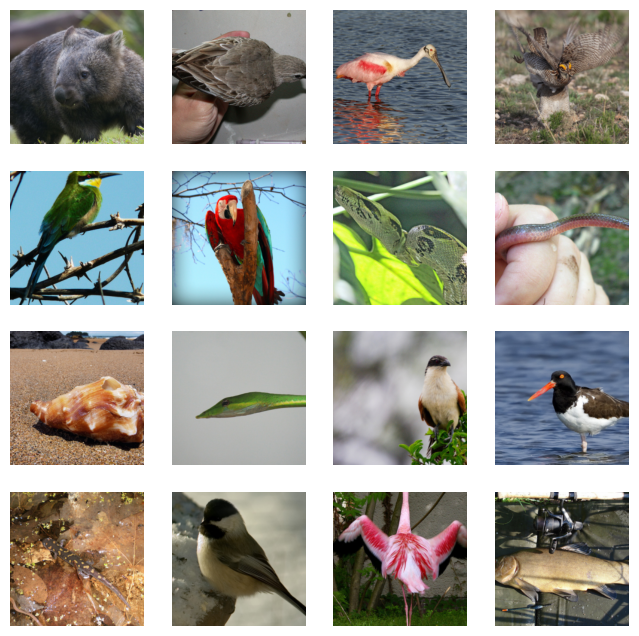

In [39]:
# display some images
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
sample_imgs = imgs[:16]  # take first 16 images
sample_imgs = sample_imgs.cpu().permute(0, 2, 3, 1) * torch.tensor(std).view(1, 1, 1, 3) + torch.tensor(mean).view(1, 1, 1, 3)
sample_imgs = torch.clamp(sample_imgs, 0, 1).numpy()
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_imgs[i])
    ax.axis('off')
plt.show()

In [40]:
# Nettoyer les anciens hooks
for _, module in model.named_modules():
    if hasattr(module, '_forward_hooks'):
        module._forward_hooks.clear()

# Setup: créer les hooks pour extraire Q, K, QK, b
qk_by_layer = {}
b_by_layer = {}

def make_qk_b_hook(name):
    def hook(module, input, output):
        x = input[0]  # [B, T, C]
        B, T, _ = x.shape
        H, D = module.num_heads, module.head_dim

        # Extraire Q, K du qkv projection
        q = module.q(x).reshape(B, T, H, D).transpose(1, 2)  # (B, H, T, D)
        k = module.k(x).reshape(B, T, H, D).transpose(1, 2)  # (B, H, T, D)

        # Calculer QK logits
        qk = (q @ k.transpose(-2, -1)) * module.scale  # [B, H, T, T]
        qk_by_layer[name] = qk[0].cpu()

        # Extraire le biais b (si defini)
        if module.b is not None:
            b = module.b(x)  # [B, T, H]
            b = b.permute(0, 2, 1)  # [B, H, T]
            b_by_layer[name] = b[0].cpu()
        else:
            b_by_layer[name] = torch.zeros(module.num_heads, T)
    return hook

# Enregistrer les hooks sur tous les modules .self_attention
layer_names = []
for name, module in model.named_modules():
    if name.endswith(".self_attention"):
        module.register_forward_hook(make_qk_b_hook(name))
        layer_names.append(name)

# Forward pass pour remplir les dictionnaires
with torch.no_grad():
    _ = model(tensor.to(device))

# Trier les layer_names par index
layer_names = sorted(layer_names, key=lambda x: int(x.split('encoder_layer_')[1].split('.')[0]))

In [ ]:
# Visualiser: QK, b, QK+b, softmax(QK+b), softmax(b)

output_dir = "../results/attention_maps"
os.makedirs(output_dir, exist_ok=True)

for layer_idx, name in enumerate(layer_names):
    qk = qk_by_layer[name]
    b = b_by_layer[name]
    n_heads = qk.shape[0]

    fig, axes = plt.subplots(5, n_heads, figsize=(18, 15))
    fig.suptitle(f"Layer {layer_idx}", fontsize=20)

    for head in range(n_heads):
        qk_h = qk[head]
        b_h_map = b[head].unsqueeze(0).repeat(qk_h.shape[0], 1)
        sum_map = qk_h + b_h_map

        amp = max(qk_h.abs().max().item(), b_h_map.abs().max().item(), sum_map.abs().max().item()) + 1e-12
        vmin, vmax = -amp, amp

        for ax, data, label in [(axes[0, head], qk_h, f"QK h{head}"), (axes[1, head], b_h_map, f"b h{head}"), (axes[2, head], sum_map, f"QK+b h{head}")]:
            ax.imshow(data.numpy(), cmap="RdBu_r", vmin=vmin, vmax=vmax)
            dmin, dmax = data.min().item(), data.max().item()
            ax.set_title(f"{label}\namp={amp:.2f} [{dmin:.2f},{dmax:.2f}]", fontsize=9)
            ax.axis("off")

        attn_with_b = torch.softmax(sum_map, dim=-1)
        axes[3, head].imshow(attn_with_b.numpy(), cmap="viridis", vmin=0.0, vmax=attn_with_b.max().item())
        axes[3, head].set_title(f"softmax(QK+b) h{head}\nmax={attn_with_b.max().item():.3f}", fontsize=9)
        axes[3, head].axis("off")

        attn_b = torch.softmax(b_h_map, dim=-1)
        axes[4, head].imshow(attn_b.numpy(), cmap="viridis", vmin=0.0, vmax=attn_b.max().item())
        axes[4, head].set_title(f"softmax(b) h{head}\nmax={attn_b.max().item():.3f}", fontsize=9)
        axes[4, head].axis("off")

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(f"{output_dir}/layer_{layer_idx}_qk_b_qkplusb_with_softmax.png")
    plt.close(fig)

In [ ]:
# Scatter plots: b vs mean(QK), b vs mean(QK+b)

output_dir = "../results/scatter_plots"
os.makedirs(output_dir, exist_ok=True)

def safe_corr(x, y):
    x, y = np.asarray(x), np.asarray(y)
    return np.corrcoef(x, y)[0, 1] if x.std() > 1e-12 and y.std() > 1e-12 else np.nan

for layer_idx, name in enumerate(layer_names):
    b = b_by_layer[name]
    qk = qk_by_layer[name]
    n_heads = qk.shape[0]

    fig, axes = plt.subplots(2, n_heads, figsize=(20, 7))
    fig.suptitle(f"Layer {layer_idx}: b vs logits", fontsize=14)

    for head in range(n_heads):
        b_vec = b[head]
        qk_h = qk[head]
        y_qk = qk_h.mean(dim=0).numpy()
        y_qkpb = (qk_h + b_vec.unsqueeze(0)).mean(dim=0).numpy()

        b_np = b_vec.numpy()
        c1, c2 = safe_corr(b_np, y_qk), safe_corr(b_np, y_qkpb)

        # Ligne 1: b vs mean(QK)
        axes[0, head].scatter(b_np, y_qk, s=12, alpha=0.8)
        axes[0, head].set_title(f"h{head} QK (r={c1:.2f})", fontsize=9)
        axes[0, head].grid(True, alpha=0.3)
        axes[0, head].set_xlabel("b")
        axes[0, head].set_ylabel("mean(QK)")

        # Ligne 2: b vs mean(QK+b)
        axes[1, head].scatter(b_np, y_qkpb, s=12, alpha=0.8)
        axes[1, head].set_title(f"h{head} QK+b (r={c2:.2f})", fontsize=9)
        axes[1, head].grid(True, alpha=0.3)
        axes[1, head].set_xlabel("b")
        axes[1, head].set_ylabel("mean(QK+b)")

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(f"{output_dir}/layer_{layer_idx}_scatter_b_qk.png")
    plt.close(fig)

In [47]:
# Visualiser le nombre de tokens prunes par layer

method = "bias_topk" if params.bias_topk is not None else "bias_score_threshold" if params.bias_score_threshold is not None else "no pruning"

def get_attention_pruning_metrics_per_layer(model):
    base_model = model._orig_mod if hasattr(model, "_orig_mod") else model

    pruned_ratios = []
    for module in base_model.modules():
        if hasattr(module, "last_pruned_ratio"):
            pruned_ratios.append(module.last_pruned_ratio.detach().item())

    return pruned_ratios


with torch.no_grad():
    imgs, labels = next(iter(val_loader))
    imgs = imgs.to(device)
    output = model(imgs)
    pruned_ratios_per_layer = get_attention_pruning_metrics_per_layer(model)


plt.figure(figsize=(8, 4))
plt.plot(pruned_ratios_per_layer, marker="o")
plt.xlabel("Layer")
plt.ylabel("Pruned columns ratio")
plt.title("Pruned columns ratio per layer, method: " + method)
plt.xticks(range(len(pruned_ratios_per_layer)))
plt.grid(True)
plt.tight_layout()
plt.savefig(f"../results/pruned_ratios_per_layer_{method}.png")
plt.close()


In [48]:
# Afficher la distribution des biais pour chaque head (6 heads) de chaque layer

output_dir = "../results/bias_distributions"
os.makedirs(output_dir, exist_ok=True)

for layer_idx, layer_name in enumerate(layer_names):
    b = b_by_layer[layer_name].detach().cpu()  # [6, T]

    n_heads = b.shape[0]
    fig, axes = plt.subplots(1, n_heads, figsize=(24, 5), squeeze=False)
    axes = axes[0]

    for head_idx in range(n_heads):
        values = b[head_idx].numpy()
        axes[head_idx].hist(values, bins=30, color="steelblue", edgecolor="black", linewidth=0.3)
        axes[head_idx].set_title(f"Head {head_idx}", fontsize=10)
        axes[head_idx].set_xlabel("Bias")
        axes[head_idx].set_ylabel("Number of tokens")
        axes[head_idx].grid(True, alpha=0.25)

    fig.suptitle(f"Bias distribution - Layer {layer_idx}", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    out_path = f"{output_dir}/bias_distribution_layer_{layer_idx:02d}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)